# FCI MTG Zarr quicklook

Open the EUMETSAT Zarr store and plot four timesteps from `data_2km`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

endpoint_url = "https://s3.r1.cloud.eumetsat.int"
bucket_name = "fci-mtg.level1c.zarr"
store_url = f"s3://{bucket_name}/sample-data.zarr/data_2km"

# XXX: this hangs, I think due to two things I think:
# 1. The zarr store is not consolidated, so it has to read the metadata from many files.
# 2. The time coordinate value is chunked with a chunk size of 1, so many many
#    small requests have to made to fetch is coordinate value
# ds = xr.open_zarr(
#     store_url,
#     chunks="auto",
#     storage_options={"anon": True, "endpoint_url": endpoint_url},
#     consolidated=False,
# )


In [2]:
base = "s3://fci-mtg.level1c.zarr/sample-data.zarr/data_1km"
opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.r1.cloud.eumetsat.int"},
}

# `create_default_indexes=False` stops xarray from trying to create the default
# indexes, which would require reading the time coordinate values, which is
# slow because they are chunked with a chunk size of 1. Although of course the
# resulting dataset now doesn't have any indexes set up so we can't do things
# like `ds.sel(time="2023-01-01")` without first creating an index on the time
# coordinate.
ds = xr.open_zarr(
    base,
    consolidated=False,
    storage_options=opts,
    create_default_indexes=False,
)
ds

<xarray.Dataset> Size: 845TB
Dimensions:        (time: 77406, y: 11136, x: 11136, channel: 8)
Coordinates:
    time           (time) datetime64[s] 619kB dask.array<chunksize=(1,), meta=np.ndarray>
    y              (y) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    x              (x) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    longitude      (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
    latitude       (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
Dimensions without coordinates: channel
Data variables:
    counts         (time, y, x, channel) uint16 154TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    channel_name   (channel) |S16 128B dask.array<chunksize=(8,), meta=np.ndarray>
    slope          (time, channel) float64 5MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    offset         (time, channel) float64 5MB dask.array<chunksize=(1, 8), meta=np.ndarray>
    pixel_quality  (time, y, x, channel) uint8 77TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    pixel_time     (time, y, x, channel) datetime64[ns] 614TB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    spatial_ref    int8 1B ...
Attributes:
    Conventions:  CF-1.8
    title:        MTG FCI Level 1C effective radiances (1km)
    institution:  EUMETSAT
    source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
    history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [3]:
# select by index number rather than value works just fine
ds.isel(time=slice(0, 100))

<xarray.Dataset> Size: 1TB
Dimensions:        (time: 100, y: 11136, x: 11136, channel: 8)
Coordinates:
    time           (time) datetime64[s] 800B dask.array<chunksize=(1,), meta=np.ndarray>
    y              (y) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    x              (x) float64 89kB dask.array<chunksize=(11136,), meta=np.ndarray>
    longitude      (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
    latitude       (y, x) float32 496MB dask.array<chunksize=(3013, 11136), meta=np.ndarray>
Dimensions without coordinates: channel
Data variables:
    counts         (time, y, x, channel) uint16 198GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    channel_name   (channel) |S16 128B dask.array<chunksize=(8,), meta=np.ndarray>
    slope          (time, channel) float64 6kB dask.array<chunksize=(1, 8), meta=np.ndarray>
    offset         (time, channel) float64 6kB dask.array<chunksize=(1, 8), meta=np.ndarray>
    pixel_quality  (time, y, x, channel) uint8 99GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    pixel_time     (time, y, x, channel) datetime64[ns] 794GB dask.array<chunksize=(1, 278, 11136, 1), meta=np.ndarray>
    spatial_ref    int8 1B ...
Attributes:
    Conventions:  CF-1.8
    title:        MTG FCI Level 1C effective radiances (1km)
    institution:  EUMETSAT
    source:       Meteosat Third Generation Flexible Combined Imager (FCI) Le...
    history:      Ingested to Zarr by firecube-mtg-fci-l1c

In [4]:
# print out the sample coordinate values (select on time first so that we dont have to load all the chunks)
ds_ = ds.isel(time=slice(0, 4))
counts = ds_["counts"]
channel_names = [name.decode("utf-8") if isinstance(name, (bytes, bytearray)) else str(name) for name in ds_["channel_name"].values]
time_values = ds_["time"].values

print("counts shape:", counts.shape)
print("channels:", channel_names)
# XXX: all timesteps appear to be NaT?
print("first timestamps:", time_values[:4])

counts shape: (4, 11136, 11136, 8)
channels: ['vis_04', 'vis_05', 'vis_06', 'vis_08', 'vis_09', 'nir_13', 'nir_16', 'nir_22']
first timestamps: ['NaT' 'NaT' 'NaT' 'NaT']


In [5]:
# select the very first timestep, the first two channels, and a 500x500 pixel region in the middle of the image. This is a small enough slice that it should be able to be read into memory without issue.
nx = ds.sizes["x"]
ny = ds.sizes["y"]
xilim = slice(nx//2 - 250, nx//2 + 250)
yilim = slice(ny//2 - 250, ny//2 + 250)
da = ds.isel(time=0, channel=slice(0, 2), x=xilim, y=yilim)["counts"]
da

<xarray.DataArray 'counts' (y: 500, x: 500, channel: 2)> Size: 1MB
dask.array<getitem, shape=(500, 500, 2), dtype=uint16, chunksize=(258, 500, 1), chunktype=numpy.ndarray>
Coordinates:
    y          (y) float64 4kB dask.array<chunksize=(500,), meta=np.ndarray>
    x          (x) float64 4kB dask.array<chunksize=(500,), meta=np.ndarray>
    longitude  (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    latitude   (y, x) float32 1MB dask.array<chunksize=(500, 500), meta=np.ndarray>
    time       datetime64[s] 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: channel
Attributes:
    units:                1
    long_name:            FCI raw detector counts
    grid_mapping:         spatial_ref
    ancillary_variables:  pixel_quality pixel_time

In [6]:
# XXX: read is quite slow (>30s) even though only a single chunk should be read?
da = da.load()

[array(65535, dtype=uint16), array(65535, dtype=uint16), array(65535.)]

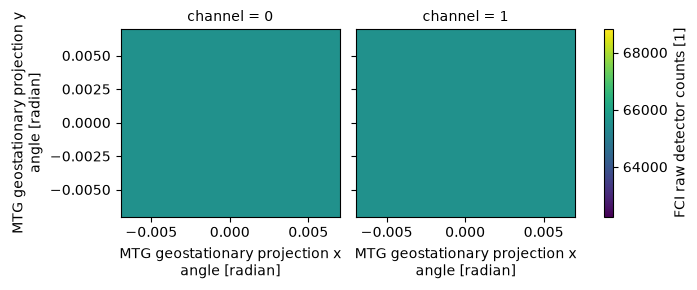

In [7]:
# XXX: all values appear to be 65535, which is the maximum value for a uint16.
# This seems to indicate that the data is not being read correctly. Perhaps the
# data is compressed in some way that xarray does not understand? Or perhaps
# the data is not actually stored in the zarr store at all, and instead is just
# a placeholder value?
da.plot(col="channel")
[da_.values for da_ in [da.min(), da.max(), da.mean()]]

In [8]:
# attempt at masking nan values before plotting, but this doesn't work because the values are still 65535

time_indices = list(range(counts.sizes["time"] - 6, counts.sizes["time"] - 2))
channel_idx = 0
channel_name = channel_names[channel_idx]

coarse = counts.isel(time=time_indices[0], channel=channel_idx, y=slice(None, None, 128), x=slice(None, None, 128)).values
ys, xs = np.argwhere(coarse != 65535)[0]
y0 = max(ys * 128 - 256, 0)
x0 = max(xs * 128 - 256, 0)
y1 = min(y0 + 512, counts.sizes["y"])
x1 = min(x0 + 512, counts.sizes["x"])

preview = []
for t_idx in time_indices:
    image = counts.isel(time=t_idx, y=slice(y0, y1), x=slice(x0, x1), channel=channel_idx).values.astype(np.float32)
    image[image == 65535] = np.nan
    preview.append(image)

stack = np.stack(preview)
vmin, vmax = np.nanpercentile(stack, [2, 98])
print(f"plotting y={y0}:{y1}, x={x0}:{x1}, channel={channel_name}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
for ax, t_idx, image in zip(axes.flat, time_indices, preview):
    im = ax.imshow(image, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"timestep {t_idx} | {channel_name}")
    ax.set_axis_off()

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="counts")
fig.suptitle("FCI MTG sample-data.zarr / data_2km", y=1.02)
plt.show()

ValueError: not enough values to unpack (expected at least 1, got 0)

IndexError: index 0 is out of bounds for axis 0 with size 0